In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import torch
import os
from torch import nn
import torchvision
from scipy import ndimage
from torchvision.transforms import v2
from torchvision import datasets
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import matplotlib.pyplot as plt
from scipy import ndimage
import numpy as np
from scipy.ndimage import distance_transform_edt
from scipy.ndimage import binary_erosion
from tqdm.auto import tqdm

In [ ]:
transform = v2.Compose([
    v2.ToImage(),
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomVerticalFlip(p=0.5),
    v2.ToDtype(torch.float32, scale=True),
])
base_transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
])

In [6]:
test_imgs_dir = r'D:\learning_ml\u_net\unmodified-data\test\imgs'
test_labels_dir = r'D:\learning_ml\u_net\unmodified-data\test\labels'
train_imgs_dir = r'D:\learning_ml\u_net\unmodified-data\train\imgs'
train_labels_dir = r'D:\learning_ml\u_net\unmodified-data\train\labels'

checkpoint_dir = r'D:\learning_ml\u_net\checkpoint'
os.makedirs(checkpoint_dir, exist_ok=True)
best_model_path = os.path.join(checkpoint_dir, 'best_unet_model.pt')

In [7]:
class weight_map():
    def __init__(self, label_img):
        self.label_img = label_img
        self.new_cell, self.label_count = self.cell_label(self.label_img)
        self.dist = self.boundary_dist()
        self.dist = np.sort(self.dist, axis=0)
        self.d1 = self.dist[0]
        self.d2 = self.dist[1]
        self.wx = torch.tensor(self.weight_generator())

    def cell_label(self, label_img):
        cell_mask = label_img > 0
        structure = np.ones((3,3))
        new_cell, label_count = ndimage.label(
            cell_mask,
            structure
        )
        return new_cell, label_count

    def boundary_dist(self):
        dist = []
        for i in range (1, self.label_count+1):
            cell = self.new_cell == i
            eroded = binary_erosion(cell)
            boundary = cell ^ eroded
            temp = distance_transform_edt(~boundary)
            dist.append(temp)
        output = np.stack(dist)
        return output

    def weight_generator(self):
        cell_mask = self.label_img > 0
        foreground_pixels = np.sum(cell_mask)
        background_pixels = np.sum(~cell_mask)

        total_pixels = foreground_pixels+background_pixels

        f_fg = foreground_pixels/total_pixels
        f_bg = background_pixels/total_pixels

        w_fg = 1/f_fg
        w_bg = 1/f_bg

        wc = np.where(
            cell_mask,
            w_fg,
            w_bg
        )

        w0 = 10
        sigma = 5
        boundary_weight = w0 * np.exp(-(self.d1+self.d2)**2/(2*(sigma)**2))

        wx = wc + boundary_weight

        return wx


In [8]:
class img2img (Dataset):
    def __init__ (self, imgs_dir, labels_dir):
        super().__init__()
        self.imgs_dir = imgs_dir
        self.labels_dir = labels_dir

        self.imgs_sorted = sorted(os.listdir(imgs_dir))
        self.labels_sorted = sorted(os.listdir(labels_dir))
    def __len__(self):
        return len(self.imgs_sorted)
    def __getitem__(self, index):
        img_path = os.path.join(self.imgs_dir, self.imgs_sorted[index])
        label_path = os.path.join(self.labels_dir, self.labels_sorted[index])

        img = np.array(Image.open(img_path).convert("L"))
        label =np.array(Image.open(label_path).convert("L"))
        return img, label

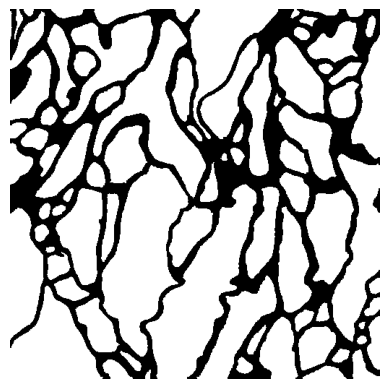

In [13]:
train_dataset = img2img(train_imgs_dir, train_labels_dir)
test_dataset = img2img(test_imgs_dir, test_labels_dir)
plt.imshow(test_dataset[15][1], cmap="gray")
plt.axis("off")
plt.show()

In [77]:
def elacstic_deformation(img, label, alpha = 10):

    img_2d = img.squeeze(0).numpy()
    label_2d = label.squeeze(0).numpy()
    h,w = img_2d.shape
    dx = np.random.normal(0, alpha, (3,3))
    dy = np.random.normal(0, alpha, (3,3))

    dx = ndimage.zoom(dx, (h/3, w/3), order=3)
    dy = ndimage.zoom(dy, (h/3, w/3), order=3)

    y, x = np.meshgrid(
        np.arange(h),
        np.arange(w),
        indexing="ij"
    )

    new_x = x + dx
    new_y = y + dy

    image_deformed = ndimage.map_coordinates(img_2d, [new_y, new_x], order = 3, mode="reflect")
    label_deformed = ndimage.map_coordinates(label_2d, [new_y, new_x], order = 0, mode = "constant", cval=0)
    image_deformed = torch.from_numpy(image_deformed).unsqueeze(0)
    label_deformed = torch.from_numpy(label_deformed).unsqueeze(0)
    return image_deformed, label_deformed

In [78]:
class conv(nn.Module):
    def __init__(self, input, output):
        super().__init__()
        self.conv_layer = nn.Conv2d(in_channels=input, out_channels=output, kernel_size=3, stride=1)
    def forward(self, x):
        return self.conv_layer(x)

class horizontal(nn.Module):
    def __init__(self, c1, c2, c3):
        super().__init__()
        self.c1, self.c2, self.c3 = c1, c2, c3
        self.layer1 = conv(c1,c2)
        self.layer2 = conv(c2,c3)
        self.relu = nn.ReLU(inplace=True)
        self.in1 = nn.InstanceNorm2d(c2)
        self.in2 = nn.InstanceNorm2d(c3)

    def forward(self, x):
        x = self.layer1(x)
        x = self.in1(x)
        x = self.relu(x)
        x = self.layer2(x)
        x = self.in2(x)
        x = self.relu(x)
        return x

class max_pool(nn.Module):
    def __init__(self):
        super().__init__()
        self.block = nn.MaxPool2d(kernel_size=2, stride=2)
    def forward(self, x):
        x = self.block(x);
        return x

class up (nn.Module):
    def __init__(self,c1,c2):
        super().__init__()
        self.layer = nn.ConvTranspose2d(c1, c2, 2, 2)
    def forward(self, x):
        return self.layer(x)

def crop_concatenate(left, right):
    _, _, lefth, leftw = left.shape
    _, _, righth, rightw = right.shape

    croph = (lefth-righth)//2
    cropw = (leftw-rightw)//2

    croped_left = left[
        : ,
        : ,
        croph:croph+righth,
        cropw:cropw+rightw
    ]

    output = torch.concat(
        [croped_left, right],
        dim = 1
    )

    return output

def lcrop(label, segmentation_map):
    _, _, labelh, labelw = label.shape
    _, _, segmentation_maph, segmentation_mapw = segmentation_map.shape

    croph = (labelh-segmentation_maph)//2
    cropw = (labelw-segmentation_mapw)//2

    croped_label = label[
        : ,
        : ,
        croph : croph + segmentation_maph,
        cropw : cropw + segmentation_mapw
    ]
    return croped_label
class unet(nn.Module):
    def __init__(self):
        super().__init__()
        self.llayer1 = horizontal(1, 64, 64)
        self.llayer2 = horizontal(64, 128, 128)
        self.llayer3 = horizontal(128, 256, 256)
        self.llayer4 = horizontal(256, 512, 512)
        self.llayer5 = horizontal(512, 1024, 1024)
        self.down = max_pool()
        self.up1 = up(1024, 512)
        self.up2 = up(512, 256)
        self.up3 = up(256,128)
        self.up4 = up(128, 64)
        self.rlayer1 = horizontal(1024, 512, 512)
        self.rlayer2 = horizontal(512, 256, 256)
        self.rlayer3 = horizontal(256,128,128)
        self.rlayer4 = horizontal(128,64,64)
        self.conv1 = nn.Conv2d(64, 2, 1)

    def forward(self, x):
        ol1 = self.llayer1(x)
        ol2 = self.llayer2(self.down(ol1))
        ol3 = self.llayer3(self.down(ol2))
        ol4 = self.llayer4(self.down(ol3))
        ol5 = self.llayer5(self.down(ol4))
        r1 = self.up1(ol5)
        ri1 = crop_concatenate(ol4, r1)
        r2 = self.up2(self.rlayer1(ri1))
        ri2 = crop_concatenate(ol3, r2)
        r3 = self.up3(self.rlayer2(ri2))
        ri3 = crop_concatenate(ol2, r3)
        r4 = self.up4(self.rlayer3(ri3))
        ri4 = crop_concatenate(ol1, r4)
        r5 = self.rlayer4(ri4)
        output = self.conv1(r5)

        return output



In [79]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


In [80]:
model = unet().to(device)

In [81]:
optimizer = torch.optim.Adam(model.parameters(), lr= 3e-4)
loss_fn = nn.CrossEntropyLoss(reduction="none")
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

In [ ]:
BATCH_SIZE = 1
train_dataloader = DataLoader(train_dataset, BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(test_dataset, BATCH_SIZE, shuffle = False)


In [ ]:
epochs = 50
best_test_loss = float('inf')

for epoch in range(epochs):
    model.train()
    train_loss = 0.0

    for img, label in train_dataloader:
        img, label = transform(img, label)
        img, label = elacstic_deformation(img, label)

        img = img.unsqueeze(0).to(device)
        label = label.unsqueeze(0)

        optimizer.zero_grad()

        segmentation_map = model(img)
        label = lcrop(label, segmentation_map)

        label_np = label.numpy().squeeze(0).squeeze(0)
        weight = weight_map(label_np)
        wx = weight.wx.to(device)

        label = (label > 0).long().squeeze(0).to(device)

        loss_map = loss_fn(segmentation_map, label)
        loss = (loss_map*wx).mean()

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_dataloader)

    model.eval()
    test_loss = 0.0


    with torch.inference_mode():
        for img, label in test_dataloader:
            img, label = base_transform(img, label)
            img = img.unsqueeze(0).to(device)
            label = label.unsqueeze(0)

            segmentation_map = model(img)
            label = lcrop(label, segmentation_map)

            label_np = label.numpy().squeeze(0).squeeze(0)
            weight = weight_map(label_np)
            wx = weight.wx.to(device)

            label = (label > 0).long().squeeze(0).to(device)

            loss_map = loss_fn(segmentation_map, label)
            loss = (loss_map*wx).mean()

            test_loss += loss.item()

    avg_test_loss = test_loss / len(test_dataloader)

    scheduler.step(avg_test_loss)

    if avg_test_loss < best_test_loss:
        best_test_loss = avg_test_loss

        checkpoint = {
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'best_test_loss': best_test_loss
        }
        torch.save(checkpoint, best_model_path)

Original: torch.Size([1, 512, 512])
Padded: torch.Size([1, 1, 696, 696])
Output: torch.Size([500, 500])


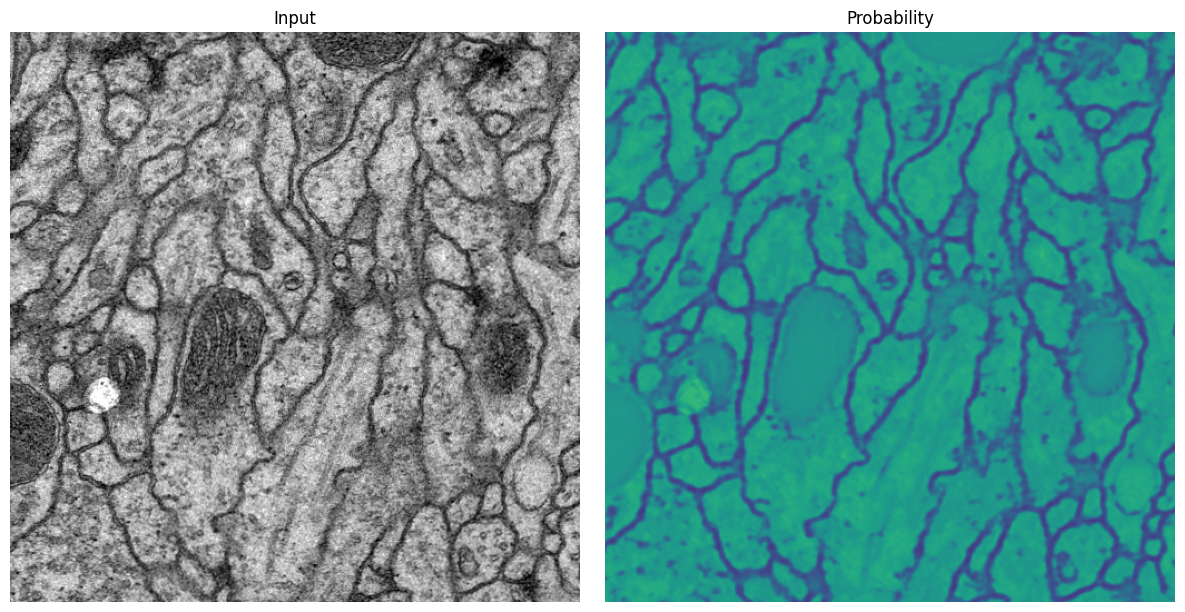

In [92]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

checkpoint = torch.load(best_model_path, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
model.to(device)
model.eval()

img, label = test_dataset[15]
img, label = base_transform(img, label)

pad = 92

padded = F.pad(
    img,
    (pad, pad, pad, pad),
    mode="reflect"
)

padded = padded.unsqueeze(0).to(device)

with torch.inference_mode():
    output = model(padded)
    probability_map = torch.softmax(output, dim=1)[:, 1]

probability_map = probability_map.squeeze(0)

binary_segmentation = (probability_map >= 0.5).to(torch.uint8)

print("Original:", img.shape)
print("Padded:", padded.shape)
print("Output:", probability_map.shape)

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(img.squeeze().cpu(), cmap="gray")
plt.title("Input")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(probability_map.cpu(), cmap="viridis", vmin=0, vmax=1)
plt.title("Probability")
plt.axis("off")


plt.tight_layout()
plt.show()